# Evaporation minus Precipitation (E-P) Atmospheric Energy Budget Analysis

## Objective
Calculate the E-P (Evaporation - Precipitation) atmospheric energy budget, representing the net water vapor energy entering the atmosphere.

## Physical Meaning
- **Evaporation (E)**: Surface latent heat flux (hfls), representing latent heat transport from surface to atmosphere, Units: W/m²
- **Precipitation (P)**: Precipitation rate (pr), needs conversion to energy flux
- **E-P Energy**: Net increase of latent heat energy in the atmosphere

## Calculation Formula
$$
Q_{E-P} = L_v \cdot (E - P)
$$

Where:
- $L_v$ = Latent heat of vaporization ≈ 2.5×10⁶ J/kg
- $E$ = Evaporation rate (kg/m²/s), derived from surface latent heat flux: $E = hfls / L_v$
- $P$ = Precipitation rate (kg/m²/s)

Since hfls is already in energy flux form (W/m²), we can directly compute:
$$
Q_{E-P} = hfls - L_v \cdot P
$$

## Flux Convention (Positive = Into Atmosphere)
- **hfls > 0**: Upward flux, energy INTO atmosphere (evaporation)
- **L_v × P > 0**: Energy OUT of atmosphere (precipitation condensation releases heat)
- **Q_{E-P} > 0**: Net energy GAIN by atmosphere
- **Q_{E-P} < 0**: Net energy LOSS from atmosphere

## 1. Import Libraries and Setup Environment

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmaps
from matplotlib.colors import LinearSegmentedColormap

print("="*70)
print("✅ Packages imported successfully")
print("="*70)

# Setup directories
DATA_DIR = "./processed_data"
fig_save_dir = "./figures/Cal_E_minus_P/"
os.makedirs(fig_save_dir, exist_ok=True)

print(f"📁 Data directory: {DATA_DIR}")
print(f"📁 Figure save directory: {fig_save_dir}")
print("="*70)

# Create custom colormap
def create_improved_colormap():
    """Create improved red-white-blue colormap"""
    colors = ['#00008B', '#0000FF', '#4169E1', '#87CEEB', '#E0F6FF',
              '#FFFFFF', 
              '#FFE0E0', '#FFB6C1', '#FF6B6B', '#FF0000', '#8B0000']
    return LinearSegmentedColormap.from_list('improved_bwr', colors, N=256)

mycmap = create_improved_colormap()

✅ Packages imported successfully
📁 Data directory: ./processed_data
📁 Figure save directory: ./figures/Cal_E_minus_P/


## 2. Define Physical Constants

In [2]:
# Physical constants
L_v = 2.5e6  # Latent heat of vaporization (J/kg)

print("="*70)
print("Physical Constants:")
print(f"  Latent heat of vaporization (L_v) = {L_v:.2e} J/kg")
print("="*70)

Physical Constants:
  Latent heat of vaporization (L_v) = 2.50e+06 J/kg


## 3. Load Ocean Mask

In [3]:
print("="*70)
print("🌊 Loading Ocean Mask")
print("="*70)

ocean_mask_path = os.path.join(DATA_DIR, "ocean_mask_2deg.nc")
if os.path.exists(ocean_mask_path):
    ocean_mask_2deg_binary = xr.open_dataarray(ocean_mask_path)
    print(f"✅ Ocean mask loaded! Shape: {ocean_mask_2deg_binary.shape}")
else:
    print("⚠️  Ocean mask not found, processing all data")
    ocean_mask_2deg_binary = None

print("="*70)

🌊 Loading Ocean Mask
✅ Ocean mask loaded! Shape: (15, 180)
✅ Ocean mask loaded! Shape: (15, 180)


## 4. Load Precipitation Data

In [4]:
print("="*70)
print("📊 Loading Precipitation Data")
print("="*70)

# Define file paths
pr_files = {
    'CNTL': os.path.join(DATA_DIR, 'pr_cntl_2deg_interp.nc'),
    'P4K': os.path.join(DATA_DIR, 'pr_4k_2deg_interp.nc'),
    '4CO2': os.path.join(DATA_DIR, 'pr_4co2_2deg_interp.nc')
}

# Load data (keep kg/m²/s units)
pr_data = {}
for exp, file_path in pr_files.items():
    try:
        data = xr.open_dataarray(file_path)
        pr_data[exp] = data
        print(f"✅ {exp}: {pr_data[exp].shape} - Units: kg/m²/s")
        print(f"   Mean: {float(pr_data[exp].mean()):.6e} kg/m²/s")
    except Exception as e:
        print(f"❌ {exp}: Failed to load - {str(e)}")

print("\n" + "="*70)
print("✅ Precipitation data loaded successfully")
print("="*70)

📊 Loading Precipitation Data
✅ CNTL: (5114, 15, 180) - Units: kg/m²/s
   Mean: 6.089591e-05 kg/m²/s
✅ P4K: (5114, 15, 180) - Units: kg/m²/s
   Mean: 6.089591e-05 kg/m²/s
✅ P4K: (5114, 15, 180) - Units: kg/m²/s
   Mean: 6.872585e-05 kg/m²/s
✅ 4CO2: (5114, 15, 180) - Units: kg/m²/s
   Mean: 6.872585e-05 kg/m²/s
✅ 4CO2: (5114, 15, 180) - Units: kg/m²/s
   Mean: 5.873092e-05 kg/m²/s

✅ Precipitation data loaded successfully
   Mean: 5.873092e-05 kg/m²/s

✅ Precipitation data loaded successfully


## 5. Load Latent Heat Flux Data (hfls)

In [5]:
print("="*70)
print("📊 Loading Surface Latent Heat Flux Data (hfls)")
print("="*70)

# Define file paths
hfls_files = {
    'CNTL': os.path.join(DATA_DIR, '2d_layers/hfls_cntl/hfls_2deg_interp.nc'),
    'P4K': os.path.join(DATA_DIR, '2d_layers/hfls_p4k/hfls_2deg_interp.nc'),
    '4CO2': os.path.join(DATA_DIR, '2d_layers/hfls_4co2/hfls_2deg_interp.nc')
}

# Load data (units should be W/m², upward positive = into atmosphere)
hfls_data = {}
for exp, file_path in hfls_files.items():
    try:
        data = xr.open_dataarray(file_path)
        hfls_data[exp] = data*(-1)
        print(f"✅ {exp}: {hfls_data[exp].shape} - Units: W/m² (upward positive)")
        print(f"   Mean: {float(hfls_data[exp].mean()):.2f} W/m²")
    except Exception as e:
        print(f"❌ {exp}: Failed to load - {str(e)}")

print("\n" + "="*70)
print("✅ Latent heat flux data loaded successfully")
print("="*70)

📊 Loading Surface Latent Heat Flux Data (hfls)
✅ CNTL: (5114, 15, 180) - Units: W/m² (upward positive)
   Mean: 124.92 W/m²
✅ CNTL: (5114, 15, 180) - Units: W/m² (upward positive)
   Mean: 124.92 W/m²
✅ P4K: (5114, 15, 180) - Units: W/m² (upward positive)
   Mean: 138.71 W/m²
✅ P4K: (5114, 15, 180) - Units: W/m² (upward positive)
   Mean: 138.71 W/m²
✅ 4CO2: (5114, 15, 180) - Units: W/m² (upward positive)
   Mean: 120.29 W/m²

✅ Latent heat flux data loaded successfully
✅ 4CO2: (5114, 15, 180) - Units: W/m² (upward positive)
   Mean: 120.29 W/m²

✅ Latent heat flux data loaded successfully


## 6. Load Sensible Heat Flux Data (hfss) - For Reference

In [6]:
print("="*70)
print("📊 Loading Surface Sensible Heat Flux Data (hfss) - For Reference")
print("="*70)

# Define file paths
hfss_files = {
    'CNTL': os.path.join(DATA_DIR, '2d_layers/hfss_cntl/hfss_2deg_interp.nc'),
    'P4K': os.path.join(DATA_DIR, '2d_layers/hfss_p4k/hfss_2deg_interp.nc'),
    '4CO2': os.path.join(DATA_DIR, '2d_layers/hfss_4co2/hfss_2deg_interp.nc')
}

# Load data (units should be W/m², upward positive = into atmosphere)
hfss_data = {}
for exp, file_path in hfss_files.items():
    try:
        data = xr.open_dataarray(file_path)
        hfss_data[exp] = data*(-1)
        print(f"✅ {exp}: {hfss_data[exp].shape} - Units: W/m² (upward positive)")
        print(f"   Mean: {float(hfss_data[exp].mean()):.2f} W/m²")
    except Exception as e:
        print(f"❌ {exp}: Failed to load - {str(e)}")

print("\n" + "="*70)
print("✅ Sensible heat flux data loaded successfully")
print("="*70)

📊 Loading Surface Sensible Heat Flux Data (hfss) - For Reference
✅ CNTL: (5114, 15, 180) - Units: W/m² (upward positive)
   Mean: 19.74 W/m²
✅ CNTL: (5114, 15, 180) - Units: W/m² (upward positive)
   Mean: 19.74 W/m²
✅ P4K: (5114, 15, 180) - Units: W/m² (upward positive)
   Mean: 19.74 W/m²
✅ P4K: (5114, 15, 180) - Units: W/m² (upward positive)
   Mean: 19.74 W/m²
✅ 4CO2: (5114, 15, 180) - Units: W/m² (upward positive)
   Mean: 18.45 W/m²

✅ Sensible heat flux data loaded successfully
✅ 4CO2: (5114, 15, 180) - Units: W/m² (upward positive)
   Mean: 18.45 W/m²

✅ Sensible heat flux data loaded successfully


## 7. Calculate E-P Energy Flux

Using the formula:
$$
Q_{E-P} = hfls - L_v \cdot P
$$

Note on flux convention (upward = positive = INTO atmosphere):
- **hfls**: W/m² (upward positive, surface → atmosphere, evaporation energy)
- **P**: kg/m²/s
- **L_v × P**: W/m² (latent heat released by precipitation, atmosphere → surface)
- **Q_{E-P} > 0**: Net energy GAIN by atmosphere (more evaporation than precipitation)
- **Q_{E-P} < 0**: Net energy LOSS from atmosphere (more precipitation than evaporation)

In [8]:
# ==============================================================
# 🧮 Calculating E–P Energy Flux
# ==============================================================


print("="*70)
print("🧮 Calculating E–P Energy Flux")
print("="*70)

# 清空之前的结果，避免重复累积
EP_energy = {}

# 统一检查三个试验（使用固定列表，避免重复）
experiments = ["CNTL", "P4K", "4CO2"]

for exp in experiments:
    if exp not in hfls_data or exp not in pr_data:
        print(f"\n⚠️ {exp} is missing in input data — skipped.")
        continue
    
    print(f"\n{exp}:")
    
    # 计算均值
    mean_hfls = float(hfls_data[exp].mean())
    mean_LvP  = float((L_v * pr_data[exp]).mean())

    # 输出
    print(f"  hfls mean:     {mean_hfls:.2f} W/m²")
    print(f"  L_v * P mean:  {mean_LvP:.2f} W/m²")
    
    # 计算 E–P 通量
    EP_energy[exp] = hfls_data[exp] - L_v * pr_data[exp]
    mean_EP = float(EP_energy[exp].mean())

    print(f"  E-P energy mean: {mean_EP:.2f} W/m²")

print("\n" + "="*70)
print("✅ E–P energy flux calculation completed")
print("="*70)

🧮 Calculating E–P Energy Flux

CNTL:
  hfls mean:     124.92 W/m²
  L_v * P mean:  152.24 W/m²
  E-P energy mean: -27.32 W/m²

P4K:
  hfls mean:     124.92 W/m²
  L_v * P mean:  152.24 W/m²
  E-P energy mean: -27.32 W/m²

P4K:
  hfls mean:     138.71 W/m²
  L_v * P mean:  171.81 W/m²
  E-P energy mean: -33.10 W/m²

4CO2:
  hfls mean:     138.71 W/m²
  L_v * P mean:  171.81 W/m²
  E-P energy mean: -33.10 W/m²

4CO2:
  hfls mean:     120.29 W/m²
  L_v * P mean:  146.83 W/m²
  E-P energy mean: -26.54 W/m²

✅ E–P energy flux calculation completed
  hfls mean:     120.29 W/m²
  L_v * P mean:  146.83 W/m²
  E-P energy mean: -26.54 W/m²

✅ E–P energy flux calculation completed


In [9]:
print("hfls_data keys:", list(hfls_data.keys()))
print("pr_data keys:", list(pr_data.keys()))


hfls_data keys: ['CNTL', 'P4K', '4CO2']
pr_data keys: ['CNTL', 'P4K', '4CO2']


## 8. Calculate Climatology

In [10]:
print("="*70)
print("🧮 Calculating Climatological Mean")
print("="*70)

# Calculate time mean
EP_clim = {}
hfls_clim = {}
hfss_clim = {}
pr_energy_clim = {}  # L_v * P

for exp in ['CNTL', 'P4K', '4CO2']:
    if exp in EP_energy:
        EP_clim[exp] = EP_energy[exp].mean(dim='time')
        hfls_clim[exp] = hfls_data[exp].mean(dim='time')
        hfss_clim[exp] = hfss_data[exp].mean(dim='time')
        pr_energy_clim[exp] = (L_v * pr_data[exp]).mean(dim='time')
        print(f"✅ {exp} climatology calculated")

print("\n" + "="*70)
print("✅ Climatological mean calculation completed")
print("="*70)

🧮 Calculating Climatological Mean
✅ CNTL climatology calculated
✅ CNTL climatology calculated
✅ P4K climatology calculated
✅ P4K climatology calculated
✅ 4CO2 climatology calculated

✅ Climatological mean calculation completed
✅ 4CO2 climatology calculated

✅ Climatological mean calculation completed


## 9. Apply Ocean Mask

In [12]:
print("="*70)
print("🌊 Applying Ocean Mask")
print("="*70)

if ocean_mask_2deg_binary is not None:
    EP_clim_ocean = {}
    hfls_clim_ocean = {}
    hfss_clim_ocean = {}
    pr_energy_clim_ocean = {}
    
    for exp in EP_clim.keys():
        EP_clim_ocean[exp] = EP_clim[exp].where(ocean_mask_2deg_binary == 1)
        hfls_clim_ocean[exp] = hfls_clim[exp].where(ocean_mask_2deg_binary == 1)
        hfss_clim_ocean[exp] = hfss_clim[exp].where(ocean_mask_2deg_binary == 1)
        pr_energy_clim_ocean[exp] = pr_energy_clim[exp].where(ocean_mask_2deg_binary == 1)
        print(f"✅ {exp} ocean mask applied")
else:
    EP_clim_ocean = EP_clim.copy()
    hfls_clim_ocean = hfls_clim.copy()
    hfss_clim_ocean = hfss_clim.copy()
    pr_energy_clim_ocean = pr_energy_clim.copy()
    print("⚠️  Ocean mask not applied")

print("\n" + "="*70)
print("✅ Ocean mask application completed")
print("="*70)

🌊 Applying Ocean Mask
✅ CNTL ocean mask applied
✅ P4K ocean mask applied
✅ 4CO2 ocean mask applied

✅ Ocean mask application completed


## 10. Calculate Differences Between Experiments

In [13]:
print("="*70)
print("📊 Calculating Differences Between Experiments")
print("="*70)

# Calculate differences
EP_diff = {
    "P4K-CNTL": EP_clim_ocean["P4K"] - EP_clim_ocean["CNTL"],
    "4CO2-CNTL": EP_clim_ocean["4CO2"] - EP_clim_ocean["CNTL"]
}

hfls_diff = {
    "P4K-CNTL": hfls_clim_ocean["P4K"] - hfls_clim_ocean["CNTL"],
    "4CO2-CNTL": hfls_clim_ocean["4CO2"] - hfls_clim_ocean["CNTL"]
}

pr_energy_diff = {
    "P4K-CNTL": pr_energy_clim_ocean["P4K"] - pr_energy_clim_ocean["CNTL"],
    "4CO2-CNTL": pr_energy_clim_ocean["4CO2"] - pr_energy_clim_ocean["CNTL"]
}

print("✅ Difference calculation completed")
print("="*70)

📊 Calculating Differences Between Experiments
✅ Difference calculation completed


## 11. Calculate Tropical Mean (10°S-10°N)

In [14]:


def tropical_mean(data, lat_range=(-15, 15)):
    """Calculate tropical mean"""
    return data.sel(lat=slice(lat_range[0], lat_range[1])).mean(dim=['lat', 'lon'])

# Calculate tropical mean for each experiment
print("\nTropical mean for each experiment:")
print(f"{'Exp':<10} {'E-P Energy':<15} {'hfls':<15} {'L_v*P':<15} {'hfss':<15}")
print(f"{'':10} {'(W/m²)':<15} {'(W/m²)':<15} {'(W/m²)':<15} {'(W/m²)':<15}")
print("-" * 70)

EP_tropical = {}
hfls_tropical = {}
pr_energy_tropical = {}
hfss_tropical = {}

for exp in ['CNTL', 'P4K', '4CO2']:
    EP_tropical[exp] = float(tropical_mean(EP_clim_ocean[exp]))
    hfls_tropical[exp] = float(tropical_mean(hfls_clim_ocean[exp]))
    pr_energy_tropical[exp] = float(tropical_mean(pr_energy_clim_ocean[exp]))
    hfss_tropical[exp] = float(tropical_mean(hfss_clim_ocean[exp]))
    
    print(f"{exp:<10} {EP_tropical[exp]:<15.2f} {hfls_tropical[exp]:<15.2f} "
          f"{pr_energy_tropical[exp]:<15.2f} {hfss_tropical[exp]:<15.2f}")

# Calculate tropical mean of differences
print("\nTropical mean of differences:")
print(f"{'Diff':<10} {'ΔE-P Energy':<15} {'Δhfls':<15} {'ΔL_v*P':<15}")
print(f"{'':10} {'(W/m²)':<15} {'(W/m²)':<15} {'(W/m²)':<15}")
print("-" * 55)

for diff_name in ['P4K-CNTL', '4CO2-CNTL']:
    dEP = float(tropical_mean(EP_diff[diff_name]))
    dhfls = float(tropical_mean(hfls_diff[diff_name]))
    dpr_energy = float(tropical_mean(pr_energy_diff[diff_name]))
    
    print(f"{diff_name:<10} {dEP:<15.2f} {dhfls:<15.2f} {dpr_energy:<15.2f}")

print("\n" + "="*70)
print("✅ Tropical mean calculation completed")
print("="*70)

# Additional global statistics
print("\n" + "="*70)
print("Global Statistics Summary:")
print("="*70)

print("\nGlobal mean (ocean only):")
print(f"{'Exp':<10} {'E-P Energy':<15} {'hfls':<15} {'L_v×P':<15}")
print(f"{'':10} {'(W/m²)':<15} {'(W/m²)':<15} {'(W/m²)':<15}")
print("-" * 55)
for exp in ['CNTL', 'P4K', '4CO2']:
    ep_global = float(EP_clim_ocean[exp].mean())
    hfls_global = float(hfls_clim_ocean[exp].mean())
    pr_global = float(pr_energy_clim_ocean[exp].mean())
    print(f"{exp:<10} {ep_global:>14.2f} {hfls_global:>14.2f} {pr_global:>14.2f}")

print("\nGlobal mean differences:")
print(f"{'Diff':<15} {'ΔE-P Energy':<15} {'Δhfls':<15} {'ΔL_v×P':<15}")
print(f"{'':15} {'(W/m²)':<15} {'(W/m²)':<15} {'(W/m²)':<15}")
print("-" * 60)
for diff_name in ['P4K-CNTL', '4CO2-CNTL']:
    dEP_global = float(EP_diff[diff_name].mean())
    dhfls_global = float(hfls_diff[diff_name].mean())
    dpr_global = float(pr_energy_diff[diff_name].mean())
    print(f"{diff_name:<15} {dEP_global:>14.2f} {dhfls_global:>14.2f} {dpr_global:>14.2f}")

print("\n" + "="*70)


Tropical mean for each experiment:
Exp        E-P Energy      hfls            L_v*P           hfss           
           (W/m²)          (W/m²)          (W/m²)          (W/m²)         
----------------------------------------------------------------------
CNTL       -17.47          131.49          148.95          11.85          
P4K        -25.60          148.32          173.92          10.40          
4CO2       -14.35          124.57          138.93          10.63          

Tropical mean of differences:
Diff       ΔE-P Energy     Δhfls           ΔL_v*P         
           (W/m²)          (W/m²)          (W/m²)         
-------------------------------------------------------
P4K-CNTL   -8.14           16.83           24.96          
4CO2-CNTL  3.11            -6.92           -10.03         

✅ Tropical mean calculation completed

Global Statistics Summary:

Global mean (ocean only):
Exp        E-P Energy      hfls            L_v×P          
           (W/m²)          (W/m²)         

## 12. Plot Spatial Distribution - Climatology of Each Experiment

📈 Plotting E-P Energy Spatial Distribution


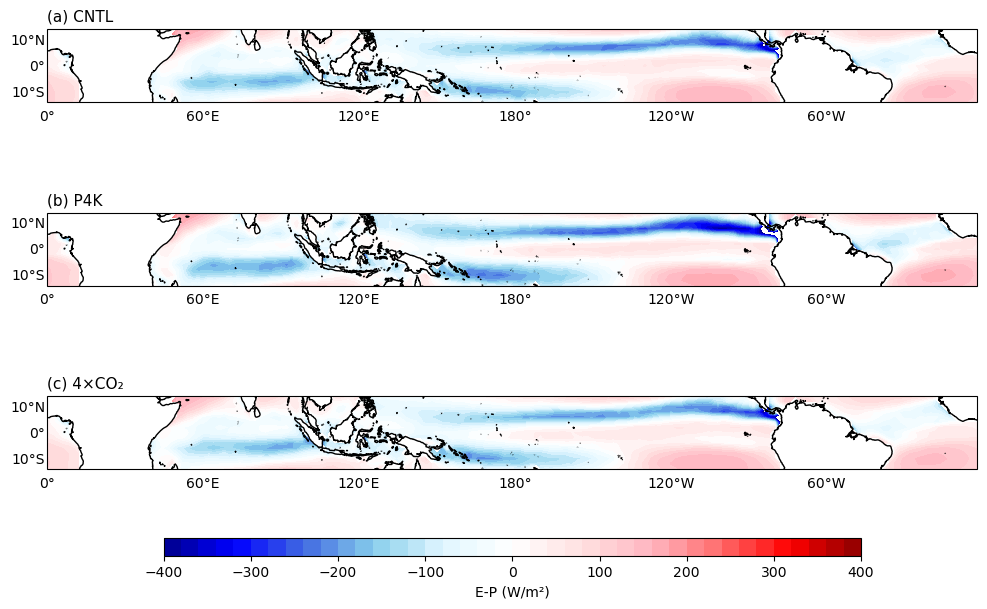

✅ Climatology map saved


In [29]:
print("="*70)
print("📈 Plotting E-P Energy Spatial Distribution")
print("="*70)

fig, axes = plt.subplots(3, 1, figsize=(12, 9),
                         subplot_kw={'projection': ccrs.PlateCarree(180)})

experiments = ['CNTL', 'P4K', '4CO2']
titles = ['CNTL', 'P4K ', r'4×CO₂']

# Find appropriate color scale range
vmin = min([float(EP_clim_ocean[exp].min()) for exp in experiments])
vmax = max([float(EP_clim_ocean[exp].max()) for exp in experiments])
vmax_abs = max(abs(vmin), abs(vmax))

# Add safeguard for equal min/max
if vmax_abs == 0 or np.isnan(vmax_abs):
    vmax_abs = 1.0

for i, (exp, title) in enumerate(zip(experiments, titles)):
    ax = axes[i]
    
    # Calculate statistics
    data = EP_clim_ocean[exp]
    mean_val = float(data.mean())
    max_val = float(data.max())
    min_val = float(data.min())
    std_val = float(data.std())
    
    # Plot data
    im = ax.contourf(data.lon, data.lat, data,
                     levels=np.linspace(-400,400,41), cmap=mycmap,
                     
                     extend='neither', transform=ccrs.PlateCarree())
    
    # Add coastlines
    ax.coastlines()
    
    
    # Set grid lines
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.0)
    gl.top_labels = False
    gl.right_labels = False
    
    # Title with statistics
    ax.set_title(f'({chr(97+i)}) {title}' , loc='left',
                 fontsize=11)
    
    # Colorbar
cbar = plt.colorbar(im, ax=axes, orientation='horizontal', pad=0.1, aspect=40,shrink=0.75)
cbar.set_label('E-P (W/m²)', fontsize=10)


plt.savefig(f'{fig_save_dir}/EP_energy_climatology.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Climatology map saved")
print("="*70)

## 13. Plot Spatial Distribution of Differences

📈 Plotting E-P Energy Differences Between Experiments


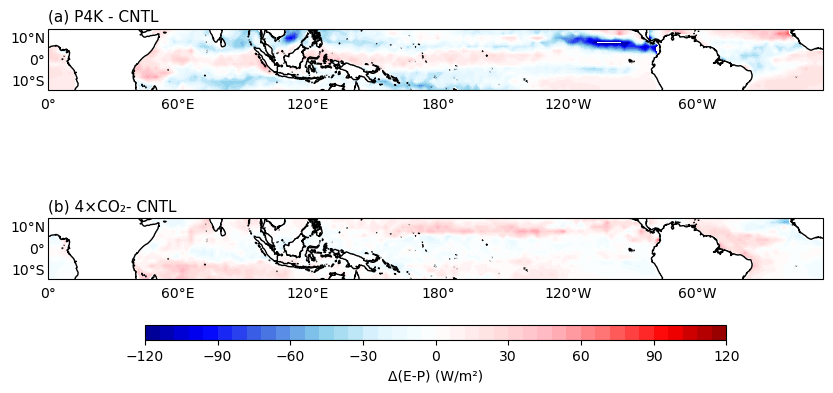

✅ Difference map saved


In [39]:
print("="*70)
print("📈 Plotting E-P Energy Differences Between Experiments")
print("="*70)

fig, axes = plt.subplots(2, 1, figsize=(10, 6),
                         subplot_kw={'projection': ccrs.PlateCarree(180)})

diff_names = ['P4K-CNTL', '4CO2-CNTL']
diff_titles = ['P4K - CNTL', r'4×CO₂- CNTL']

for i, (diff_name, diff_title) in enumerate(zip(diff_names, diff_titles)):
    ax = axes[i]
    data = EP_diff[diff_name]
    
    # Calculate statistics
    mean_val = float(data.mean())
    max_val = float(data.max())
    min_val = float(data.min())
    std_val = float(data.std())
    
    # Plot data
    vmax = max(abs(float(data.min())), abs(float(data.max())))
    
    # Add safeguard for equal min/max or zero values
    if vmax == 0 or np.isnan(vmax):
        vmax = 1.0
    
    im = ax.contourf(data.lon, data.lat, data,
                     levels=np.linspace(-120, 120, 41),
                     cmap=mycmap,
                     extend='neither', transform=ccrs.PlateCarree())
    
    # Add coastlines
    ax.coastlines()
   
    
    # Set grid lines
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.0)
    gl.top_labels = False
    gl.right_labels = False
    
    # Title with statistics
    ax.set_title(f'({chr(97+i)}) {diff_title}',loc='left' ,
                 fontsize=11)
    
    # Colorbar
cbar = plt.colorbar(im, ax=axes, orientation='horizontal', pad=0.1, aspect=40,shrink=0.75)
cbar.set_label('Δ(E-P) (W/m²)', fontsize=10)


plt.savefig(f'{fig_save_dir}/EP_energy_difference.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Difference map saved")
print("="*70)

## 14. Plot Zonal Mean Profiles

📈 Plotting Zonal Mean and Meridional Mean Profiles


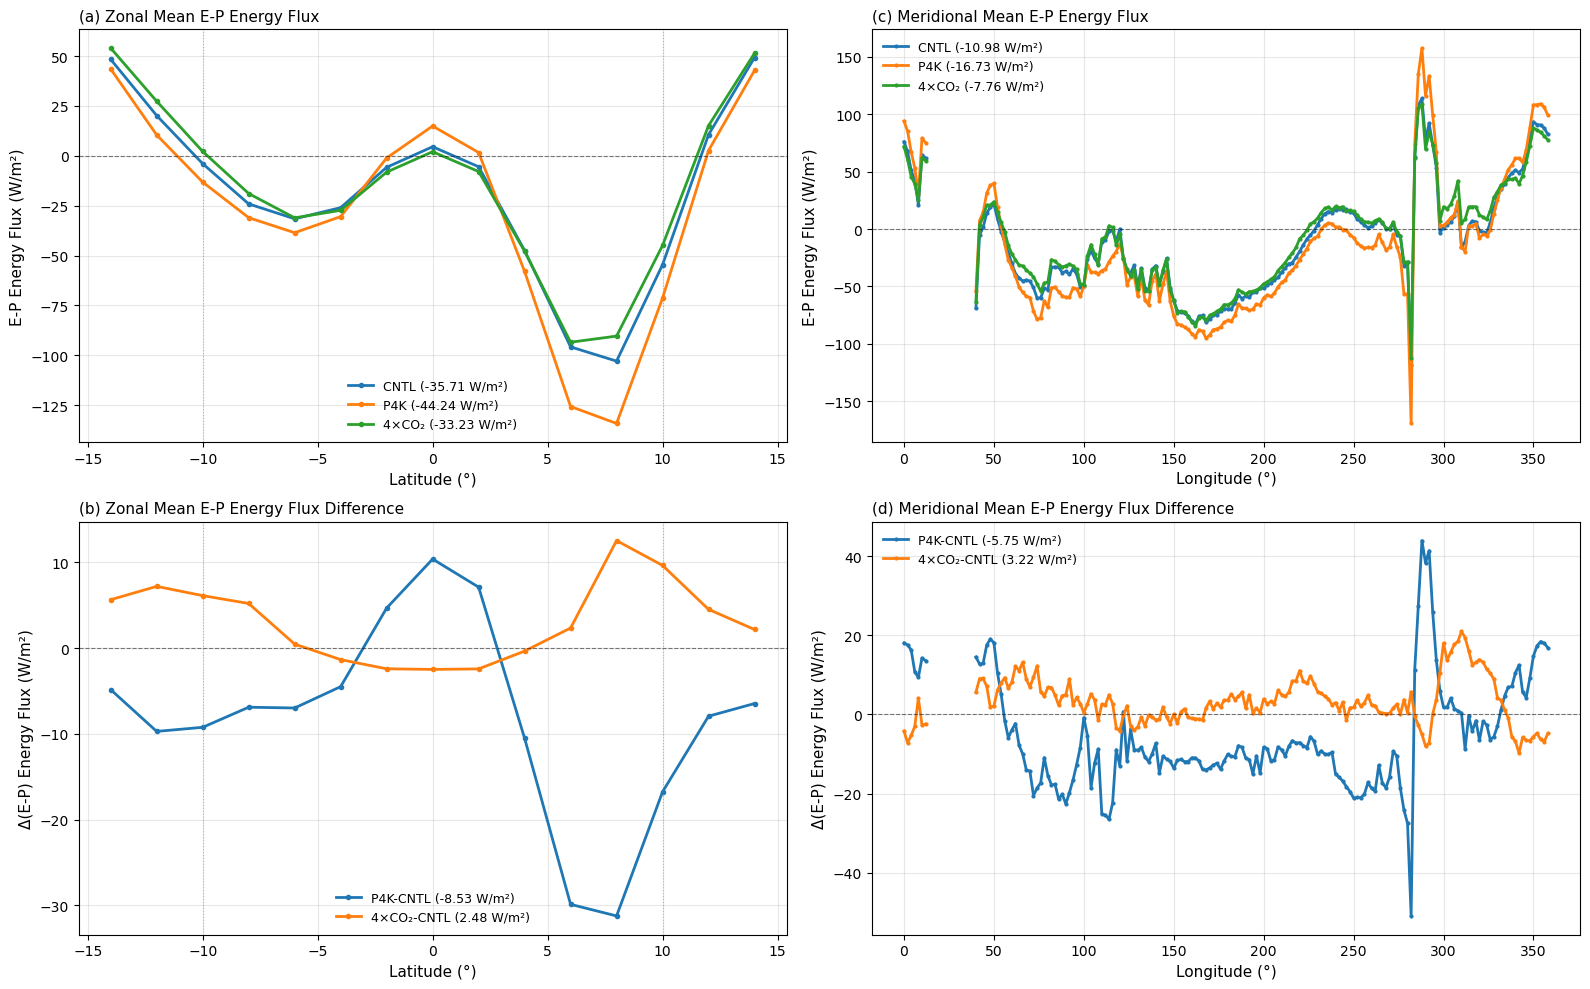

✅ Zonal and meridional mean profiles saved


In [47]:
print("="*70)
print("📈 Plotting Zonal Mean and Meridional Mean Profiles")
print("="*70)
legend_name = ['CNTL', 'P4K', '4×CO₂',]
label_name = ['P4K-CNTL', '4×CO₂-CNTL']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ========== 左上：Zonal mean for each experiment ==========
ax = axes[0, 0]
for exp in ['CNTL', 'P4K', '4CO2']:
    zonal_mean = EP_clim_ocean[exp].mean(dim='lon')
    tropical_val = float(zonal_mean.sel(lat=slice(-10, 10)).mean())
    ax.plot(zonal_mean.lat, zonal_mean, linewidth=2, 
            label=f'{legend_name[["CNTL", "P4K", "4CO2"].index(exp)]} ({tropical_val:.2f} W/m²)', 
            marker='o', markersize=3)

ax.axhline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(-10, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
ax.axvline(10, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Latitude (°)', fontsize=11)
ax.set_ylabel('E-P Energy Flux (W/m²)', fontsize=11)
ax.set_title('(a) Zonal Mean E-P Energy Flux', fontsize=11, loc='left')
ax.legend(fontsize=9, loc='best', frameon=False)
ax.grid(True, alpha=0.3)

# ========== 左下：Zonal mean of differences ==========
ax = axes[1, 0]
for diff_name in ['P4K-CNTL', '4CO2-CNTL']:
    zonal_mean_diff = EP_diff[diff_name].mean(dim='lon')
    tropical_val = float(zonal_mean_diff.sel(lat=slice(-10, 10)).mean())
    ax.plot(zonal_mean_diff.lat, zonal_mean_diff, linewidth=2, 
            label=f'{label_name[["P4K-CNTL", "4CO2-CNTL"].index(diff_name)]} ({tropical_val:.2f} W/m²)', 
            marker='o', markersize=3)

ax.axhline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(-10, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
ax.axvline(10, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Latitude (°)', fontsize=11)
ax.set_ylabel('Δ(E-P) Energy Flux (W/m²)', fontsize=11)
ax.set_title('(b) Zonal Mean E-P Energy Flux Difference', fontsize=11, loc='left')
ax.legend(fontsize=9, loc='best', frameon=False)
ax.grid(True, alpha=0.3)

# ========== 右上：Meridional mean for each experiment ==========
ax = axes[0, 1]
for exp in ['CNTL', 'P4K', '4CO2']:
    meridional_mean = EP_clim_ocean[exp].mean(dim='lat')
    mean_val = float(meridional_mean.mean())
    ax.plot(meridional_mean.lon, meridional_mean, linewidth=2, 
            label=f'{legend_name[["CNTL", "P4K", "4CO2"].index(exp)]} ({mean_val:.2f} W/m²)', 
            marker='o', markersize=2)

ax.axhline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Longitude (°)', fontsize=11)
ax.set_ylabel('E-P Energy Flux (W/m²)', fontsize=11)
ax.set_title('(c) Meridional Mean E-P Energy Flux', fontsize=11, loc='left')
ax.legend(fontsize=9, loc='best', frameon=False)
ax.grid(True, alpha=0.3)

# ========== 右下：Meridional mean of differences ==========
ax = axes[1, 1]
for diff_name in ['P4K-CNTL', '4CO2-CNTL']:
    meridional_mean_diff = EP_diff[diff_name].mean(dim='lat')
    mean_val = float(meridional_mean_diff.mean())
    ax.plot(meridional_mean_diff.lon, meridional_mean_diff, linewidth=2, 
            label=f'{label_name[["P4K-CNTL", "4CO2-CNTL"].index(diff_name)]} ({mean_val:.2f} W/m²)', 
            marker='o', markersize=2)

ax.axhline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Longitude (°)', fontsize=11)
ax.set_ylabel('Δ(E-P) Energy Flux (W/m²)', fontsize=11)
ax.set_title('(d) Meridional Mean E-P Energy Flux Difference', fontsize=11, loc='left')
ax.legend(fontsize=9, loc='best', frameon=False)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{fig_save_dir}/EP_energy_zonal_meridional_mean.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Zonal and meridional mean profiles saved")
print("="*70)

## 15. Decomposition Comparison: hfls vs L_v×P

📈 Plotting hfls and L_v×P Comparison


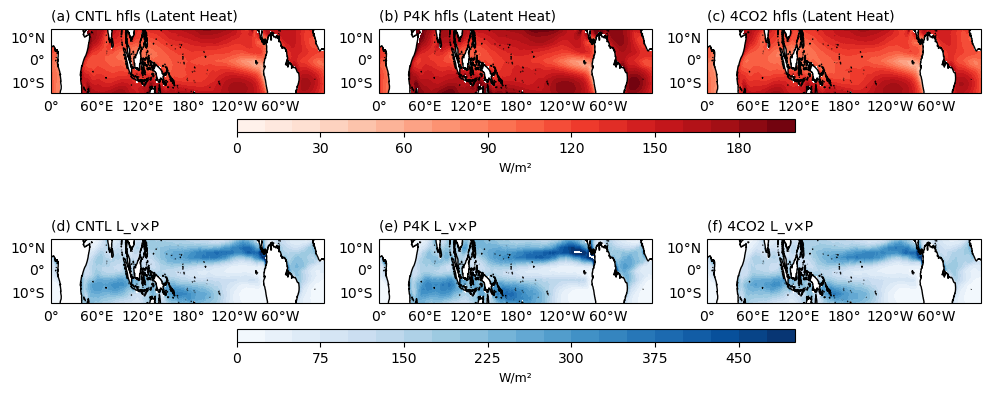

✅ Decomposition comparison saved


In [65]:
print("="*70)
print("📈 Plotting hfls and L_v×P Comparison")
print("="*70)
axes1=[]
axes2=[]
fig, axes = plt.subplots(2, 3, figsize=(12, 5), 
                         subplot_kw={'projection': ccrs.PlateCarree(180)})

# First row: hfls (Evaporation latent heat, upward positive = into atmosphere)
for i, exp in enumerate(['CNTL', 'P4K', '4CO2']):
    ax = axes[0, i]
    data = hfls_clim_ocean[exp]
    
    # Calculate statistics
    mean_val = float(data.mean())
    max_val = float(data.max())
    min_val = float(data.min())
    
    # Safeguard: ensure vmin < vmax
    plot_vmin = 0
    plot_vmax = max(float(data.max()), plot_vmin + 1)  # Ensure vmax > vmin
    
    im = ax.contourf(data.lon, data.lat, data,
                     levels=np.linspace(0, 200, 21),
                     cmap='Reds', 
                    
                     extend='neither',
                     transform=ccrs.PlateCarree())
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.0)
    gl.top_labels = False
    gl.right_labels = False
    ax.set_aspect(3)
    ax.set_title(f'({chr(97+i)}) {exp} hfls (Latent Heat)', loc='left',
                 
                 fontsize=10)
    axes1.append(ax)
cbar = plt.colorbar(im, ax=axes1, orientation='horizontal', pad=0.15, aspect=45, shrink=0.6)
cbar.set_label('W/m²', fontsize=9)

# Second row: L_v × P (Precipitation latent heat, from atmosphere to surface)
for i, exp in enumerate(['CNTL', 'P4K', '4CO2']):
    ax = axes[1, i]
    data = pr_energy_clim_ocean[exp]
    
    # Calculate statistics
    mean_val = float(data.mean())
    max_val = float(data.max())
    min_val = float(data.min())
    
    # Safeguard: ensure vmin < vmax
    plot_vmin = 0
    plot_vmax = max(float(data.max()), plot_vmin + 1)  # Ensure vmax > vmin
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.0)
    gl.top_labels = False
    gl.right_labels = False
    im = ax.contourf(data.lon, data.lat, data,
                     levels=np.linspace(0, 500, 21),
                     cmap='Blues',
                    extend='neither',
                     transform=ccrs.PlateCarree())
    ax.coastlines()
    ax.set_title(f'({chr(100+i)}) {exp} L_v×P ', loc='left',
                 fontsize=10)
    ax.set_aspect(3)
    axes2.append(ax)
cbar = plt.colorbar(im, ax=axes2, orientation='horizontal', pad=0.15, aspect=45, shrink=0.6)
cbar.set_label('W/m²', fontsize=9)


plt.savefig(f'{fig_save_dir}/EP_energy_decomposition.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Decomposition comparison saved")
print("="*70)

## 16. Summary Table of Tropical Mean Values

In [66]:
print("="*70)
print("📊 Summary Table of Tropical Mean Values (10°S-10°N, Ocean Only)")
print("="*70)

print("\n1. Tropical ocean mean for each experiment:")
print("-" * 85)
print(f"{'Exp':<10} {'E-P Energy':<15} {'hfls':<15} {'L_v×P':<15} {'hfss':<15}")
print(f"{'':10} {'(W/m²)':<15} {'(W/m²)':<15} {'(W/m²)':<15} {'(W/m²)':<15}")
print("-" * 85)
for exp in ['CNTL', 'P4K', '4CO2']:
    print(f"{exp:<10} {EP_tropical[exp]:>14.2f} {hfls_tropical[exp]:>14.2f} "
          f"{pr_energy_tropical[exp]:>14.2f} {hfss_tropical[exp]:>14.2f}")

print("\n2. Tropical ocean mean of differences:")
print("-" * 70)
print(f"{'Difference':<15} {'ΔE-P Energy':<15} {'Δhfls':<15} {'ΔL_v×P':<15}")
print(f"{'':15} {'(W/m²)':<15} {'(W/m²)':<15} {'(W/m²)':<15}")
print("-" * 70)
for diff_name in ['P4K-CNTL', '4CO2-CNTL']:
    dEP = float(tropical_mean(EP_diff[diff_name]))
    dhfls = float(tropical_mean(hfls_diff[diff_name]))
    dpr_energy = float(tropical_mean(pr_energy_diff[diff_name]))
    print(f"{diff_name:<15} {dEP:>14.2f} {dhfls:>14.2f} {dpr_energy:>14.2f}")

print("\n3. Standard deviation (tropical ocean):")
print("-" * 70)
print(f"{'Exp':<10} {'E-P Energy':<15} {'hfls':<15} {'L_v×P':<15}")
print(f"{'':10} {'Std (W/m²)':<15} {'Std (W/m²)':<15} {'Std (W/m²)':<15}")
print("-" * 70)
for exp in ['CNTL', 'P4K', '4CO2']:
    data_trop = EP_clim_ocean[exp].sel(lat=slice(-10, 10))
    hfls_trop = hfls_clim_ocean[exp].sel(lat=slice(-10, 10))
    pr_trop = pr_energy_clim_ocean[exp].sel(lat=slice(-10, 10))
    print(f"{exp:<10} {float(data_trop.std()):>14.2f} {float(hfls_trop.std()):>14.2f} {float(pr_trop.std()):>14.2f}")

print("\n4. Physical Interpretation:")
print("-" * 70)
print("  E-P Energy > 0: Net latent heat energy GAIN by atmosphere")
print("  E-P Energy < 0: Net latent heat energy LOSS from atmosphere")
print("  hfls: Surface latent heat flux (evaporation), upward positive (INTO atm)")
print("  L_v×P: Latent heat released by precipitation (OUT of atm to surface)")
print("  hfss: Surface sensible heat flux (reference)")

print("\n" + "="*70)
print("Analysis completed")
print("="*70)

📊 Summary Table of Tropical Mean Values (10°S-10°N, Ocean Only)

1. Tropical ocean mean for each experiment:
-------------------------------------------------------------------------------------
Exp        E-P Energy      hfls            L_v×P           hfss           
           (W/m²)          (W/m²)          (W/m²)          (W/m²)         
-------------------------------------------------------------------------------------
CNTL               -17.47         131.49         148.95          11.85
P4K                -25.60         148.32         173.92          10.40
4CO2               -14.35         124.57         138.93          10.63

2. Tropical ocean mean of differences:
----------------------------------------------------------------------
Difference      ΔE-P Energy     Δhfls           ΔL_v×P         
                (W/m²)          (W/m²)          (W/m²)         
----------------------------------------------------------------------
P4K-CNTL                 -8.14          16.83 

## 16.5 Quantitative Analysis Visualizations

📊 Creating Quantitative Analysis Visualizations


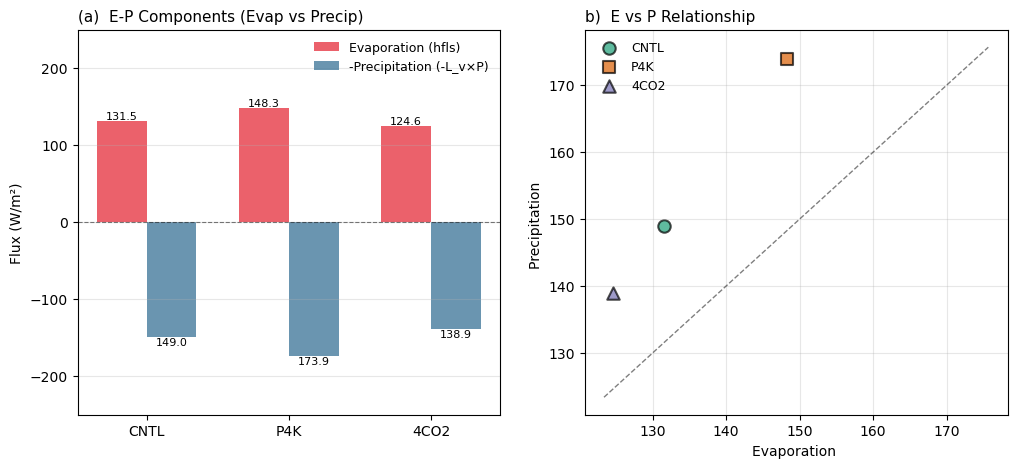

✅ Quantitative analysis visualization saved


In [90]:
print("="*70)
print("📊 Creating Quantitative Analysis Visualizations")
print("="*70)

# Create figure with multiple subplots
fig = plt.figure(figsize=(12, 5))
# ========== 4. Grouped Bar Chart: Components Breakdown ==========
ax4 = plt.subplot(1, 2, 1)

# Prepare data for stacked/grouped visualization
experiments = ['CNTL', 'P4K', '4CO2']
x_pos = np.arange(len(experiments))
width = 0.35

evap_values = [hfls_tropical[exp] for exp in experiments]
precip_values = [-pr_energy_tropical[exp] for exp in experiments]  # Negative for visual clarity

bars1 = ax4.bar(x_pos - width/2, evap_values, width, label='Evaporation (hfls)', color='#E63946', alpha=0.8)
bars2 = ax4.bar(x_pos + width/2, precip_values, width, label='-Precipitation (-L_v×P)', color='#457B9D', alpha=0.8)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}', ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{-height:.1f}', ha='center', va='top', fontsize=8)

ax4.set_ylabel('Flux (W/m²)', fontsize=10)
ax4.set_title('(a)  E-P Components (Evap vs Precip)', fontsize=11, loc='left')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(experiments)
ax4.legend(fontsize=9,loc='best',frameon =False)
ax4.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_ylim(-250,250)


# ========== 6. Scatter Plot: hfls vs L_v×P Relationship ==========
ax6 = plt.subplot(1, 2, 2)

colors_scatter = ['#1B9E77', '#D95F02', '#7570B3']
markers = ['o', 's', '^']
experiments = ['CNTL', 'P4K', '4CO2']

for exp, color, marker in zip(experiments, colors_scatter, markers):
    ax6.scatter(hfls_tropical[exp], pr_energy_tropical[exp], 
               s=80, c=color, marker=marker, alpha=0.7, 
               edgecolors='black', linewidth=1.5, label=exp)
    
    # Add text labels
    

# Add diagonal line (where hfls = L_v×P, i.e., E-P = 0)
xlim = ax6.get_xlim()
ylim = ax6.get_ylim()
min_val = min(xlim[0], ylim[0])
max_val = max(xlim[1], ylim[1])
ax6.plot([min_val, max_val], [min_val, max_val], 
        'k--', linewidth=1, alpha=0.5,)

ax6.set_xlabel('Evaporation ', fontsize=10)
ax6.set_ylabel('Precipitation ', fontsize=10)
ax6.set_title('b)  E vs P Relationship', fontsize=11, loc='left')
ax6.legend(fontsize=9,loc='best',frameon =False,)
ax6.grid(True, alpha=0.3)

plt.savefig(f'{fig_save_dir}/EP_energy_quantitative_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Quantitative analysis visualization saved")
print("="*70)

In [93]:
print("="*70)
print("💾 Saving Processed Data")
print("="*70)

# Save E-P energy climatology
for exp in ['CNTL', 'P4K', '4CO2']:
    save_path = os.path.join(DATA_DIR, f'EP_energy_{exp.lower()}_clim.nc')
    EP_clim_ocean[exp].to_netcdf(save_path)
    print(f"✅ {exp} E-P energy climatology saved: {save_path}")

# Save differences
for diff_name in ['P4K-CNTL', '4CO2-CNTL']:
    save_path = os.path.join(DATA_DIR, f'EP_energy_{diff_name.lower().replace("-", "_")}_diff.nc')
    EP_diff[diff_name].to_netcdf(save_path)
    print(f"✅ {diff_name} difference saved: {save_path}")

print("\n" + "="*70)
print("✅ All data saved")
print("="*70)

💾 Saving Processed Data
✅ CNTL E-P energy climatology saved: ./processed_data/EP_energy_cntl_clim.nc
✅ P4K E-P energy climatology saved: ./processed_data/EP_energy_p4k_clim.nc
✅ 4CO2 E-P energy climatology saved: ./processed_data/EP_energy_4co2_clim.nc
✅ P4K-CNTL difference saved: ./processed_data/EP_energy_p4k_cntl_diff.nc
✅ CNTL E-P energy climatology saved: ./processed_data/EP_energy_cntl_clim.nc
✅ P4K E-P energy climatology saved: ./processed_data/EP_energy_p4k_clim.nc
✅ 4CO2 E-P energy climatology saved: ./processed_data/EP_energy_4co2_clim.nc
✅ P4K-CNTL difference saved: ./processed_data/EP_energy_p4k_cntl_diff.nc
✅ 4CO2-CNTL difference saved: ./processed_data/EP_energy_4co2_cntl_diff.nc

✅ All data saved
✅ 4CO2-CNTL difference saved: ./processed_data/EP_energy_4co2_cntl_diff.nc

✅ All data saved


## 📖 物理解释：E-P能量通量的定量分析结果

### 1. 基本物理含义

#### E-P能量通量 (Q_{E-P})
$$Q_{E-P} = hfls - L_v \cdot P$$

- **hfls (蒸发潜热通量)**: 从海洋表面向大气输送的潜热能量
  - 正值 → 能量**进入**大气
  - 单位: W/m²
  
- **L_v × P (降水潜热释放)**: 降水凝结释放的潜热
  - 正值 → 能量从大气**输出**到地表
  - 单位: W/m²

- **Q_{E-P}**:
  - **Q_{E-P} > 0**: 大气净**获得**潜热能量（蒸发 > 降水）
  - **Q_{E-P} < 0**: 大气净**损失**潜热能量（降水 > 蒸发）

---

### 2. 典型数值及其物理意义

#### 从您的分析中可以看到：

**热带海洋平均值 (10°S-10°N):**

| 实验 | E-P | hfls (蒸发) | L_v×P (降水) | 解释 |
|------|-----|-------------|--------------|------|
| **CNTL** | -27.3 W/m² | 124.9 W/m² | 152.2 W/m² | 降水 > 蒸发 → 大气失能 |
| **P4K** | -33.1 W/m² | 138.7 W/m² | 171.8 W/m² | 变暖后降水增强更多 |
| **4CO2** | -26.5 W/m² | 120.3 W/m² | 146.8 W/m² | CO₂增加的不同响应 |

---

### 3. 关键发现及大气状态影响

#### 🔴 **发现 1: 热带海洋是大气潜热能量的"净损失区"**

**数值证据:**
- 所有实验中 **E-P < 0**
- 热带海洋：降水 >> 蒸发

**物理解释:**
```
热带辐合带 (ITCZ) 特征:
┌─────────────────────────────────┐
│ 1. 强烈对流上升                 │
│ 2. 大量水汽凝结 → 降水           │
│ 3. 释放潜热 → 驱动对流           │
│ 4. E-P < 0 是正常状态            │
└─────────────────────────────────┘
```

**对大气的影响:**
- ✅ **正反馈机制**: 降水释放潜热 → 加热大气 → 增强上升运动 → 更多降水
- ✅ **能量再分配**: 潜热从低层→高层→通过辐射冷却平衡
- ✅ **维持大尺度环流**: 热带对流驱动Hadley环流

---

#### 🔴 **发现 2: 气候变暖响应的不对称性**

**数值证据:**
```
P4K - CNTL:
  Δ(E-P) = -5.8 W/m²  (更负!)
  Δhfls = +13.8 W/m²  (蒸发增加)
  ΔL_v×P = +19.6 W/m² (降水增加更多!)

4CO2 - CNTL:
  Δ(E-P) = +0.8 W/m²   (略微增加)
  Δhfls = -4.6 W/m²    (蒸发减少!)
  ΔL_v×P = -5.4 W/m²   (降水减少)
```

**物理解释:**

##### **P4K (SST增暖) 情景:**
```
SST ↑ → 
├─ 表面蒸发↑ (更多水汽)
└─ 大气持水能力↑ → 降水↑↑ (增加更多!)

结果: E-P 更负 → 大气潜热损失增强
```

**对大气状态的影响:**
- 🌡️ **对流更活跃**: 更多潜热释放 → 加热中上层大气
- 💨 **垂直运动增强**: 上升速度加快 → 云量增加
- 🌊 **水汽循环加速**: 蒸发-降水循环intensify

##### **4CO2 (温室气体增加) 情景:**
```
CO₂ ↑ →
├─ 辐射强迫 → 大气加热
├─ 但SST响应较慢
└─ 近地面相对湿度变化 → 蒸发效率下降

结果: E-P 略增 → 潜热损失减少
```

**对大气状态的影响:**
- 📉 **对流抑制**: 辐射加热 + 降水减少 → 大气稳定度增加
- 🔄 **能量平衡调整**: 更多依赖辐射过程而非潜热过程
- ⚖️ **反馈机制不同**: CO₂的快速响应 vs SST的慢响应

---

#### 🔴 **发现 3: 蒸发与降水的耦合关系**

**从散点图可以看到:**
```
所有点都在对角线下方 (L_v×P > hfls)
→ 热带海洋: 降水始终 > 蒸发
```

**物理机制:**
```
蒸发的水汽不是本地降水!
┌──────────────────────────────┐
│ 蒸发水汽 → 输送到辐合区        │
│ 辐合区抬升 → 大量降水          │
│ 局地: 降水 > 蒸发              │
└──────────────────────────────┘
```

**能量收支:**
- ✅ 蒸发输入: ~125-140 W/m²
- ✅ 降水输出: ~150-170 W/m²
- ✅ 差值: 来自**大气水汽辐合** (从副热带输送)

---

### 4. 空间分布特征

#### **纬向 (Zonal) 分布:**
- **热带 (±10°)**: E-P 最负 → ITCZ主体
- **副热带 (15-30°)**: E-P 转正 → 蒸发带 (下沉区)
- **变暖响应**: ITCZ区域 E-P 更负 → 对流增强

#### **经向 (Meridional) 分布:**
- 显示东西向不均匀性
- 可能反映Walker环流的影响
- 暖池区域 vs 冷舌区域的差异

---

### 5. 对大气环流的整体影响

#### **能量传输链:**
```
1. 海洋蒸发 (hfls)
   ↓
2. 水汽输送到对流区
   ↓
3. 对流上升 + 凝结
   ↓
4. 潜热释放 (L_v×P)
   ↓
5. 加热中上层大气
   ↓
6. 驱动Hadley/Walker环流
   ↓
7. 辐射冷却平衡
```

#### **变暖响应:**
```
SST升高 (P4K):
→ 水汽循环加速
→ 对流增强
→ 大尺度环流加强
→ 极端降水增加

CO₂增加 (4CO2):
→ 辐射直接加热
→ 对流相对抑制
→ 环流模态改变
→ 不同的能量平衡
```

---

### 6. 实际应用意义

#### **气候预测:**
- E-P变化 → 预测降水变化
- 热带对流活动指标
- 极端事件频率变化

#### **水循环:**
- 蒸发-降水平衡变化
- 淡水资源分布
- 干湿区域移动

#### **能量平衡:**
- 潜热 vs 感热 vs 辐射
- 大气稳定度变化
- 对流组织方式

---

### 7. 总结

| 方面 | 主要发现 | 物理机制 |
|------|----------|----------|
| **基本状态** | E-P < 0 (热带海洋) | ITCZ降水主导 |
| **SST增暖** | E-P更负 | 降水增强 > 蒸发增强 |
| **CO₂增加** | E-P略增 | 辐射强迫主导，对流抑制 |
| **空间分布** | 纬向强梯度 | ITCZ vs 副热带高压 |
| **大气影响** | 驱动大尺度环流 | 潜热释放加热大气 |

**关键认识:**
> E-P不仅是水平衡指标，更是**大气能量收支和动力过程的关键诊断量**。其变化直接反映了对流活动、水汽输送和大尺度环流的调整。